import needed libraries

In [1]:
import numpy as np
import pandas as pd
import kagglehub
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array ,ImageDataGenerator
import cv2
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.optimizers import Adam ,Adagrad
from tensorflow.keras.applications import Xception
import seaborn as sns
import matplotlib.pyplot as plt
import os

Downloading dataset from kagglehub

In [2]:
path = kagglehub.dataset_download("abdulhasibuddin/uc-merced-land-use-dataset")
print(path)

Using Colab cache for faster access to the 'uc-merced-land-use-dataset' dataset.
/kaggle/input/uc-merced-land-use-dataset


Saving images address to a DataFrame

In [3]:
Images_folder = os.path.join(path , "UCMerced_LandUse/Images")

data = []

for label_idx, folder in enumerate(os.listdir(Images_folder)):
    folder_path = os.path.join(Images_folder, folder)
    for fname in os.listdir(folder_path):
        if fname.lower().endswith(('.tif', '.jpg', '.jpeg')):
            data.append({
                'filepath': os.path.join(folder_path, fname),
                'label': label_idx
            })

df = pd.DataFrame(data)


Split dataset to Train and Test sets (80/20)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["filepath"], df["label"], test_size=0.2, random_state=42, shuffle=True , stratify = df["label"]
)


We can plot the dataset distribution

<BarContainer object of 21 artists>

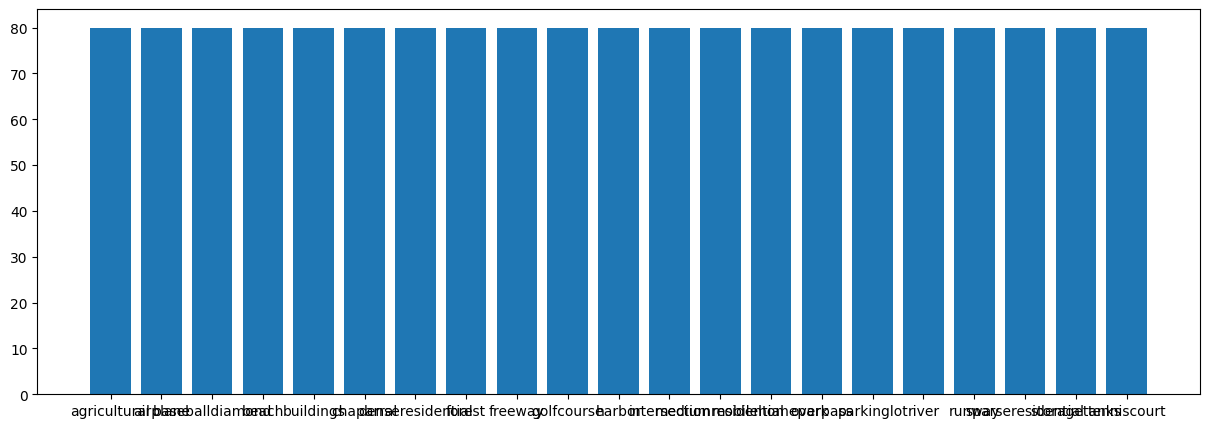

In [5]:
class_mapping = {0:'agricultural' , 1:'airplane' , 2:'baseballdiamond' , 3:'beach' , 4:'buildings' , 5:'chaparral',
                 6:'denseresidential',7:'forest', 8:'freeway' , 9:'golfcourse' , 10:'harbor' , 11:'intersection' ,
                 12:'mediumresidential' ,13:'mobilehomepark', 14:'overpass' , 15:'parkinglot', 16:'river' ,
                 17:'runway' , 18:'sparseresidential' , 19:'storagetanks' , 20:'tenniscourt'}


bar = {}
for i in np.unique(y_train):
    bar[class_mapping[i]] = 0

for i in y_train :
    bar[class_mapping[i]] += 1

plt.figure(figsize=(15,5))
plt.bar(bar.keys() , bar.values())

<BarContainer object of 21 artists>

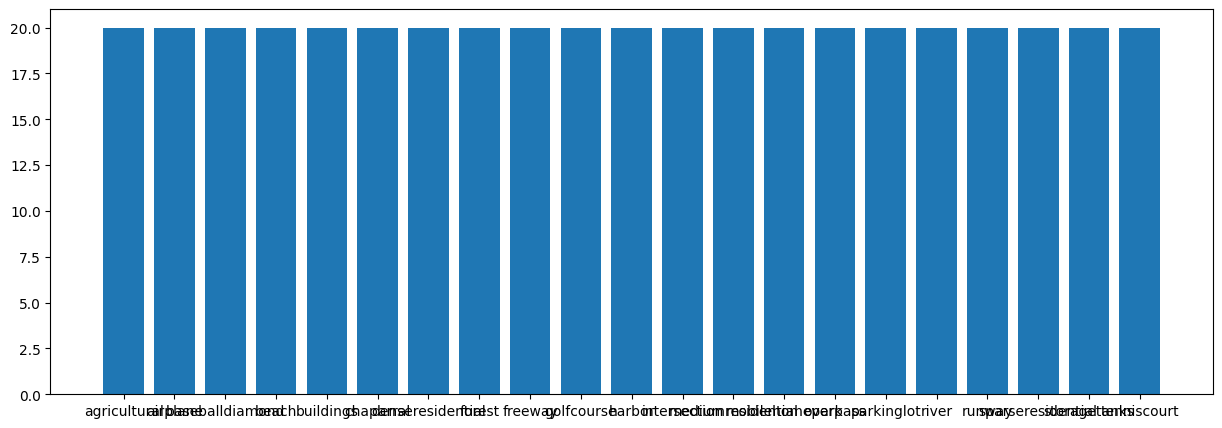

In [6]:
bar = {}
for i in np.unique(y_test):
    bar[class_mapping[i]] = 0

for i in y_test :
    bar[class_mapping[i]] += 1

plt.figure(figsize=(15,5))
plt.bar(bar.keys() , bar.values())

Creating random_zooming and Augmentations functions

In [7]:
def random_zooming(x, zoom_factor=1.2):
    h, w, c = x.shape
    crop_h = int(h / zoom_factor)
    crop_w = int(w / zoom_factor)

    start_h = np.random.randint(0, h - crop_h + 1)
    start_w = np.random.randint(0, w - crop_w + 1)

    cropped = x[start_h:start_h+crop_h, start_w:start_w+crop_w, :]

    zoomed = cv2.resize(cropped, (w, h))

    return zoomed.astype('uint8')

In [ ]:
def Augmentations(x):
    
    augmented = []
    augmented.append(x)
    augmented.append(np.rot90(x, k=1))
    augmented.append(np.rot90(x, k=2))
    augmented.append(np.flipud(x))
    augmented.append(np.fliplr(x))
    augmented.append(random_zooming(x, zoom_factor=1.5))
    
    return augmented



Augmented a random image

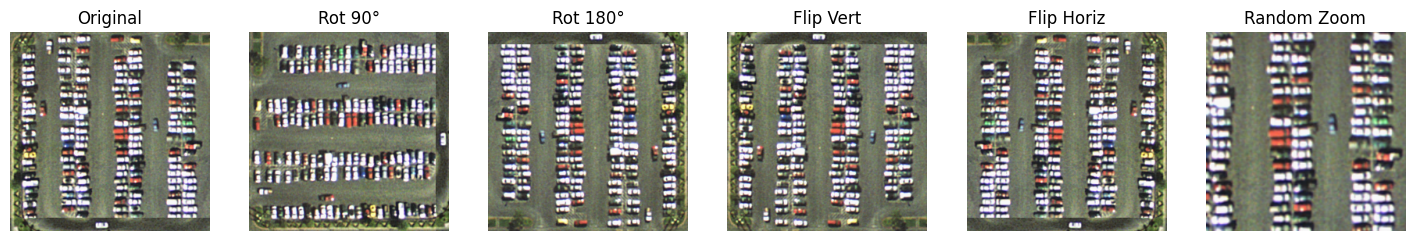

In [18]:
random_img = df.iloc[450]['filepath']
loading_image = load_img(random_img)
arr = img_to_array(loading_image)
aug_images = Augmentations(arr)
plt.figure(figsize=(18, 6))

titles = ['Original', 'Rot 90°', 'Rot 180°', 'Flip Vert', 'Flip Horiz', 'Random Zoom']

for i, img in enumerate(aug_images):
    plt.subplot(1, 6, i+1)
    plt.imshow(img.astype('uint8'))
    plt.axis('off')
    plt.title(titles[i])

plt.show()


Creating image_generator function for reading and augmented raw images

In [19]:
IMG_SIZE = (299, 299)

def image_generator(df, batch_size=36 , augmented = True):

    assert batch_size % 6 == 0

    n = len(df)
    indices = np.arange(n)

    while True:
        np.random.shuffle(indices)

        batch_x = []
        batch_y = []

        for idx in indices:

            row = df.iloc[idx]
            img = cv2.imread(row['filepath'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)

            if augmented:
              aug_images = Augmentations(img)

              for im in aug_images:
                  im = preprocess_input(im)
                  batch_x.append(im)
                  batch_y.append(row['label'])

            else :
              img = preprocess_input(img)
              batch_x.append(img)
              batch_y.append(row['label'])

            if len(batch_x) == batch_size:
                yield (
                np.array(batch_x[:batch_size]),
                np.array(batch_y[:batch_size])
                )
                batch_x = []
                batch_y = []



In [20]:
train_df = pd.DataFrame({
    'filepath':X_train ,
    'label':y_train
})
val_df = pd.DataFrame({
    'filepath':X_test ,
    'label':y_test
})


<h1> Creating the CNN + MLP model

Download and creating model

In [21]:
model = Xception(weights='imagenet', include_top=False)

Freezing the CNN's weights

In [22]:
for layer in model.layers:
    layer.trainable = False


Creatin MLP function for classification

In [23]:
def MLP(model):

  num_of_classes = 21

  x = model.output

  x = layers.GlobalAveragePooling2D()(x)

  x = layers.BatchNormalization()(x)

  x = layers.Dense(2048, activation='sigmoid')(x)

  x = layers.Dropout(0.4)(x)

  output = layers.Dense(num_of_classes, activation='softmax')(x)

  model = models.Model(inputs=model.input, outputs=output)
  return model


Using Adagard optimizer and compile the model

In [ ]:
optimizer = Adagrad(
    learning_rate=0.1,
    epsilon=1e-07,
)

model = MLP(model)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



Summary of model

In [25]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, None,      │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, None,      │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, None,      │          0 │ block1_conv1_bn[… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, None,      │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, None,      │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, None,      │          0 │ block1_conv2_bn[… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, None,      │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, None,      │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, None,      │          0 │ block2_sepconv1_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, None,      │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, None,      │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │      8,192 │ block1_conv2_act… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, None,      │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, None,      │          0 │ block2_pool[0][0… │
│                     │ None, 128)        │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, None,      │          0 │ add_12[0][0]    

 Total params: 25,109,053 (95.78 MB)

 Trainable params: 4,243,477 (16.19 MB)

 Non-trainable params: 20,865,576 (79.60 MB)

Creating train and validation generators for feeding to the model

In [27]:
batch_size = 54
steps_per_epoch = len(train_df) * 6 // batch_size
validation_steps = len(val_df) // batch_size

train_gen = image_generator(train_df , batch_size = batch_size)
val_gen = image_generator(val_df , batch_size = batch_size)


We can train our model

In [ ]:
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50,
)


Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 112s 348ms/step - accuracy: 0.3570 - loss: 2.4235 - val_accuracy: 0.8258 - val_loss: 0.7397
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 286ms/step - accuracy: 0.8018 - loss: 0.6861 - val_accuracy: 0.8687 - val_loss: 0.3946
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 284ms/step - accuracy: 0.8377 - loss: 0.5285 - val_accuracy: 0.8990 - val_loss: 0.2875
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 284ms/step - accuracy: 0.8707 - loss: 0.4270 - val_accuracy: 0.9798 - val_loss: 0.1157
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 284ms/step - accuracy: 0.8823 - loss: 0.3809 - val_accuracy: 0.9066 - val_loss: 0.2794
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 284ms/step - accuracy: 0.8928 - loss: 0.3470 - val_accuracy: 0.9596 - val_loss: 0.1509
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 284ms/step - accuracy: 0.9091 - loss: 0.2993 - val_accuracy: 0.9470 - val_loss: 0.1680
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 79s 284ms/step - accuracy: 0.9018 - loss: 

Creating a function to evaluate the model and plotting the results

In [ ]:
IMGSIZE = 299
def load_and_preprocess(path): 
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMGSIZE, IMGSIZE))
    img = preprocess_input(img.astype('float32'))
    return img

def evaluation (model , history ,x_test , y_test):
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'])
  plt.show()

  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Model Loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'])
  plt.show()

  X_test_ready = np.stack([load_and_preprocess(p) for p in X_test])
  y_test_array = np.array(y_test)
  test_loss, test_acc = model.evaluate(X_test_ready, y_test_array, batch_size=32)
  print("Test accuracy:", test_acc)

  y_pred = model.predict(X_test_ready)
  y_pred_cls = y_pred.argmax(axis=1)

  cm = confusion_matrix(y_test, y_pred_cls)

  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.show()


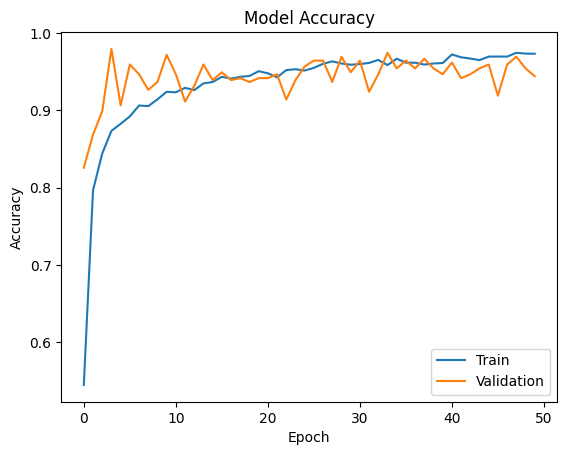

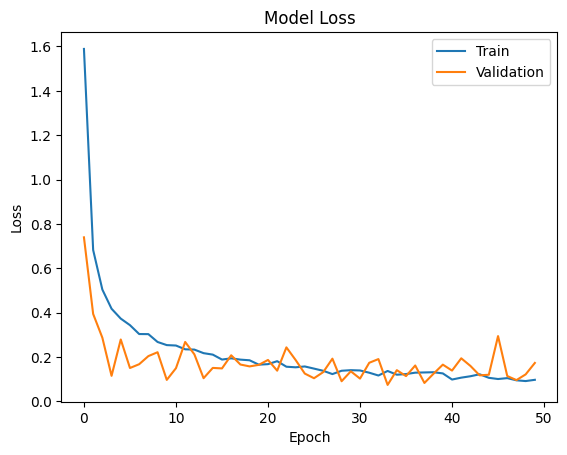

14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 993ms/step - accuracy: 0.9715 - loss: 0.0819
Test accuracy: 0.9595237970352173
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step


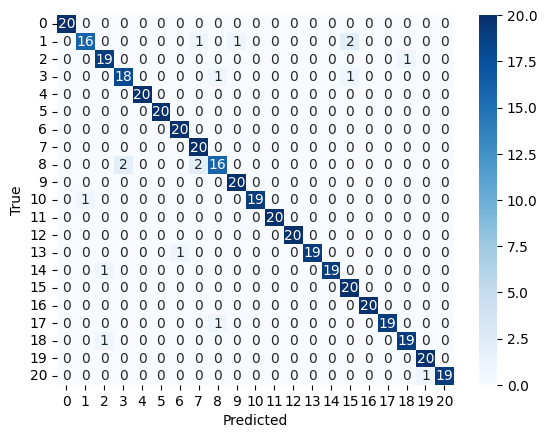

In [ ]:
evaluation(model,history , X_test , y_test)

<h1>Fully Connected Model

In last layer we using softmax layer for classification

In [ ]:
model_top = Xception(weights='imagenet', include_top=True)

for layer in model_top.layers[:-1]:
    layer.trainable = False

x = model_top.layers[-2].output

x = layers.Dense(21, activation='softmax', name='predictions')(x)

model = models.Model(inputs=model_top.input, outputs=x)

optimizer = Adagrad(
    learning_rate=0.01,
    epsilon=1e-07,
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

train_gen = image_generator(train_df , batch_size = 36)
val_gen = image_generator(val_df , batch_size = 36)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50,
)

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 128s 321ms/step - accuracy: 0.5000 - loss: 2.1337 - val_accuracy: 0.8611 - val_loss: 0.9401
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 79s 284ms/step - accuracy: 0.8934 - loss: 0.7888 - val_accuracy: 0.8864 - val_loss: 0.6612
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 79s 283ms/step - accuracy: 0.9211 - loss: 0.5454 - val_accuracy: 0.9369 - val_loss: 0.4002
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 79s 283ms/step - accuracy: 0.9229 - loss: 0.4469 - val_accuracy: 0.8611 - val_loss: 0.5436
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 79s 283ms/step - accuracy: 0.9263 - loss: 0.4037 - val_accuracy: 0.9066 - val_loss: 0.4080
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 82s 293ms/step - accuracy: 0.9364 - loss: 0.3571 - val_accuracy: 0.9293 - val_loss: 0.3709
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 79s 283ms/step - accuracy: 0.9445 - loss: 0.2948 - val_accuracy: 0.9419 - val_loss: 0.3565
Epoch 8/50
280/280 ━━━━━━━━━━━━

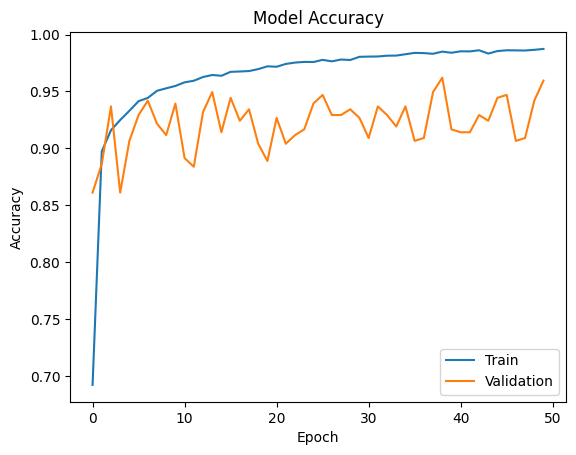

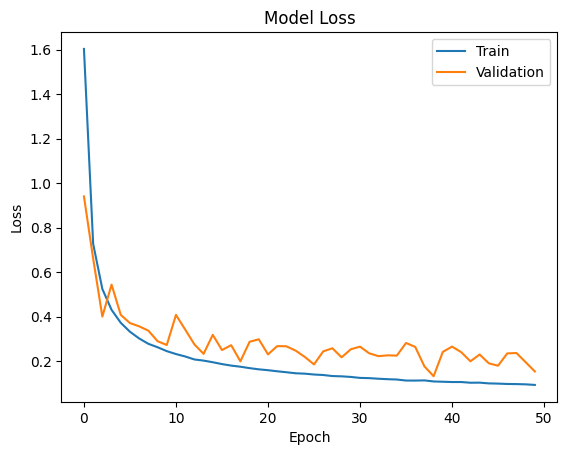

14/14 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9657 - loss: 0.1451
Test accuracy: 0.9523809552192688
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 998ms/step


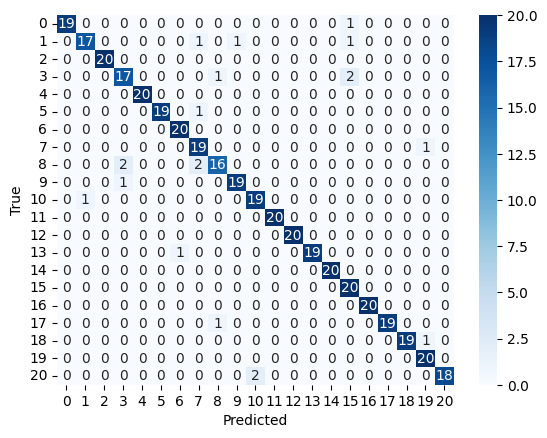

In [ ]:
evaluation(model,history , X_test , y_test)

<h1> Augmentation Effect

train the model without any augmentation

In [ ]:
train_gen = image_generator(train_df , batch_size = 36 , augmented = False)
val_gen = image_generator(val_df ,batch_size = 36, augmented = False)


In [ ]:
model = Xception(weights='imagenet', include_top=False)
for layer in model.layers:
    layer.trainable = False

optimizer = Adagrad(
    learning_rate=0.01,
    epsilon=1e-07,
)

model = MLP(model)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch//6,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50,
)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 589ms/step - accuracy: 0.1906 - loss: 2.7694 - val_accuracy: 0.2879 - val_loss: 2.4312
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 348ms/step - accuracy: 0.7353 - loss: 1.0897 - val_accuracy: 0.5884 - val_loss: 1.9342
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 345ms/step - accuracy: 0.8534 - loss: 0.7104 - val_accuracy: 0.8258 - val_loss: 1.4236
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 336ms/step - accuracy: 0.8759 - loss: 0.5395 - val_accuracy: 0.8510 - val_loss: 1.1093
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 333ms/step - accuracy: 0.8937 - loss: 0.4637 - val_accuracy: 0.9167 - val_loss: 0.7900
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 339ms/step - accuracy: 0.9203 - loss: 0.3671 - val_accuracy: 0.9167 - val_loss: 0.5905
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 341ms/step - accuracy: 0.9333 - loss: 0.3101 - val_accuracy: 0.9369 - val_loss: 0.4801
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 342ms/step - accuracy: 0.9341 - loss: 0.2918 - val_accu

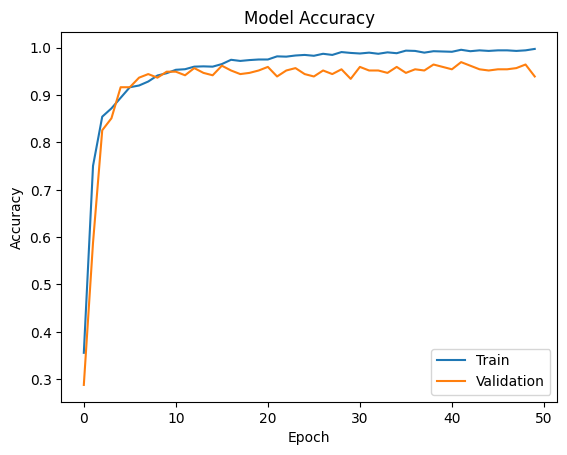

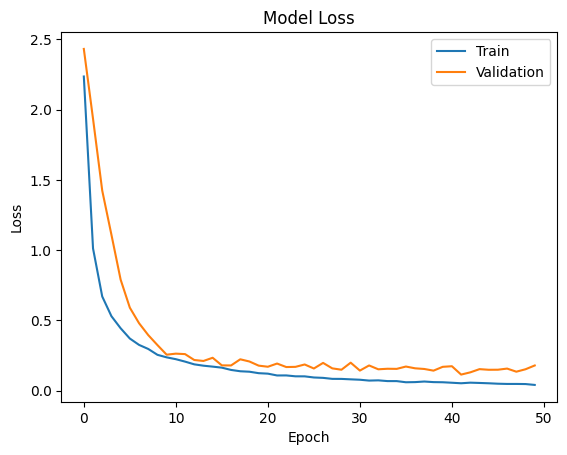

14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 960ms/step - accuracy: 0.9741 - loss: 0.1241
Test accuracy: 0.9595237970352173
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step


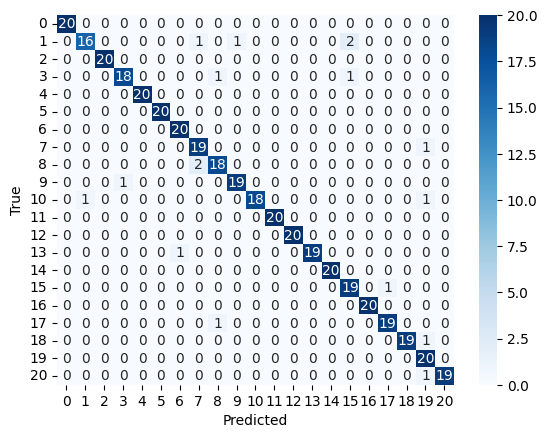

In [ ]:
evaluation(model,history , X_test , y_test)

<h1> ADAM Optimizer

creat the CNN+MLP model with ADAM optimizer

In [ ]:
model = Xception(weights='imagenet', include_top=False)
for layer in model.layers:
    layer.trainable = False

model = MLP(model)

optimizer = Adam(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
train_gen = image_generator(train_df , batch_size = 36)
val_gen = image_generator(val_df , batch_size = 36)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50,
)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 107s 326ms/step - accuracy: 0.4977 - loss: 5.8347 - val_accuracy: 0.7551 - val_loss: 0.8671
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 286ms/step - accuracy: 0.7548 - loss: 0.9202 - val_accuracy: 0.8687 - val_loss: 0.6644
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 285ms/step - accuracy: 0.7882 - loss: 1.0106 - val_accuracy: 0.8813 - val_loss: 0.8448
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 285ms/step - accuracy: 0.7968 - loss: 1.0348 - val_accuracy: 0.8737 - val_loss: 0.8959
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 284ms/step - accuracy: 0.8050 - loss: 1.1559 - val_accuracy: 0.8965 - val_loss: 0.6454
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 285ms/step - accuracy: 0.8041 - loss: 1.2457 - val_accuracy: 0.9293 - val_loss: 0.3103
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 82s 293ms/step - accuracy: 0.8292 - loss: 1.1813 - val_accuracy: 0.9293 - val_loss: 0.6073
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 285ms/step - accuracy: 0.8331 - loss: 

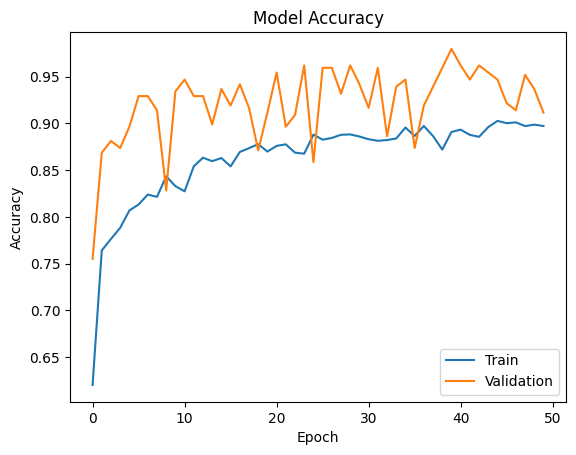

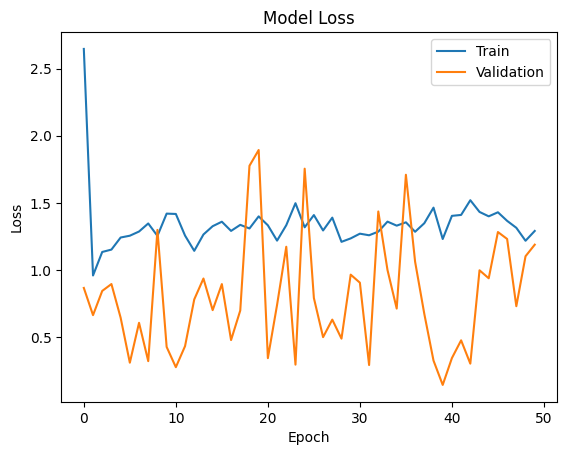

14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 948ms/step - accuracy: 0.9358 - loss: 0.6426
Test accuracy: 0.9261904954910278
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step


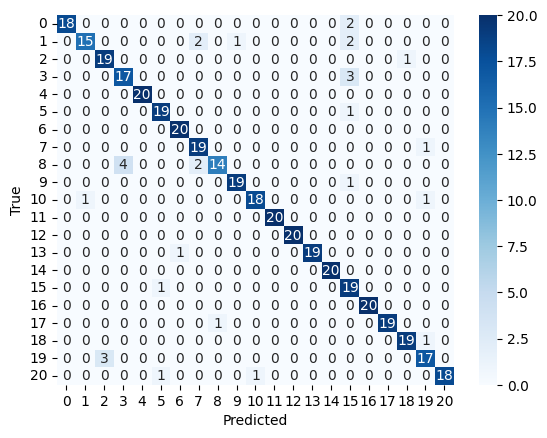

In [ ]:
evaluation(model,history , X_test , y_test)

<h1> Fine-Tuning

fine-tune the last 10 layers

In [ ]:
model = Xception(weights='imagenet', include_top=True)
for layer in model.layers[:-20]:
    layer.trainable = False

x = model.layers[-2].output

x = layers.Dense(21, activation='softmax', name='predictions')(x)
model = models.Model(inputs=model.input, outputs=x)

optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
train_gen = image_generator(train_df , batch_size = 54)
val_gen = image_generator(val_df , batch_size = 54)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50,
)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 172s 426ms/step - accuracy: 0.6237 - loss: 1.3507 - val_accuracy: 0.8763 - val_loss: 0.5111
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 109s 390ms/step - accuracy: 0.9062 - loss: 0.3186 - val_accuracy: 0.9394 - val_loss: 0.2596
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 109s 389ms/step - accuracy: 0.9307 - loss: 0.2322 - val_accuracy: 0.9369 - val_loss: 0.1483
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 108s 387ms/step - accuracy: 0.9549 - loss: 0.1488 - val_accuracy: 0.9747 - val_loss: 0.0974
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 109s 388ms/step - accuracy: 0.9712 - loss: 0.1005 - val_accuracy: 0.9722 - val_loss: 0.0804
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 108s 387ms/step - accuracy: 0.9786 - loss: 0.0752 - val_accuracy: 0.9394 - val_loss: 0.1699
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 109s 388ms/step - accuracy: 0.9659 - loss: 0.1053 - val_accuracy: 0.9747 - val_loss: 0.0578
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 109s 388ms/step - accuracy: 0.9841 -

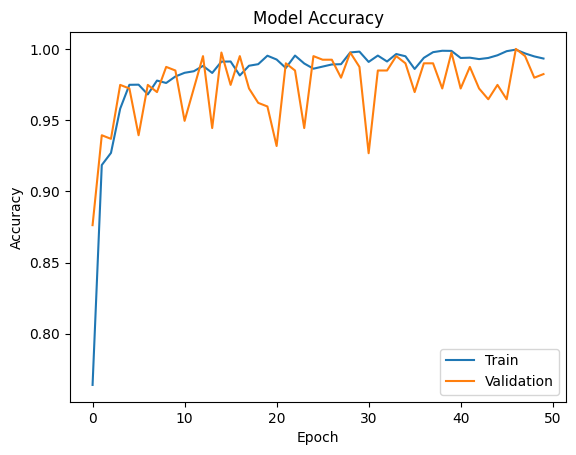

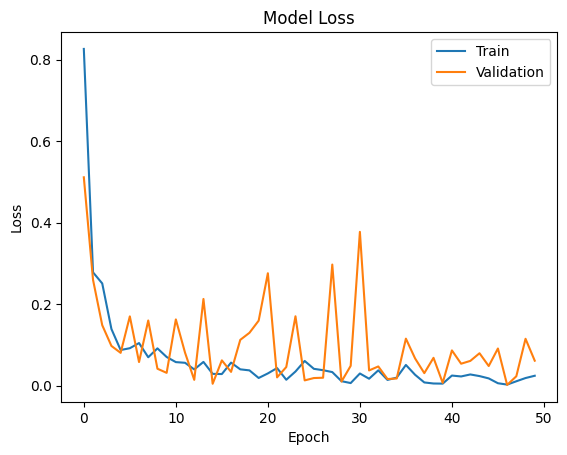

14/14 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9818 - loss: 0.0583
Test accuracy: 0.9785714149475098
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step


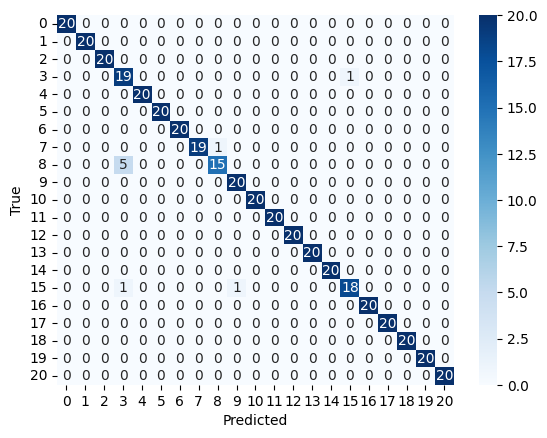

In [ ]:
evaluation(model,history , X_test , y_test)